In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from functools import partial
from scipy.optimize import minimize
import pandas as pd
import random
import matplotlib

# Марковские процессы

1. Пусть Xt – марковский процесс с непрерывным временем, м.п.и. которого имеет вид

Q =

−4 1 3

2 −3 1

3 2 −5


Найти м.в.п. вложенной цепи, моделировать Xt с помощью вложенной цепи.

In [2]:
Q_matrix = np.array([[-4, 1, 3],
                     [2, -3, 1],
                     [3, 2, -5]])

def find_inner_mc(q_matrix):
    # get inner markov chain matrix
    n = q_matrix.shape[0]
    transition_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                transition_matrix[i,j] = -(q_matrix[i,j]/q_matrix[i,i])
    return transition_matrix

def get_trajectory(matrix, start_state = 0, num_steps = 100):
    #model markov chain
    n = matrix.shape[0]
    trajectory = np.zeros(num_steps)
    x = start_state
    for i in range(1, num_steps):
        x = random.choices(np.arange(n), weights = matrix[x], k=1)[0]
        trajectory[i] = x
    return trajectory

find_inner_mc(Q_matrix)

def model_markov_process(q_matrix, start_state = 0, num_steps = 100):
    #model markov process = chain x + time t
    transition_matrix = find_inner_mc(q_matrix)
    x = get_trajectory(transition_matrix, start_state=start_state, num_steps = num_steps)
    t = np.zeros(num_steps)
    for i in range(num_steps):
        state = int(x[i])
        t[i] = stats.expon.rvs(scale = -1/q_matrix[state, state])
    return x, t

def draw_markov_process(x, t):
    #draw markov process trajectory
    n = len(x)
    past = 0
    for i in range(n):
        l = np.linspace(past, past + t[i] , 100)
        plt.hlines(x[i], past, past+t[i], color ='salmon')
        past += t[i]
    plt.show()

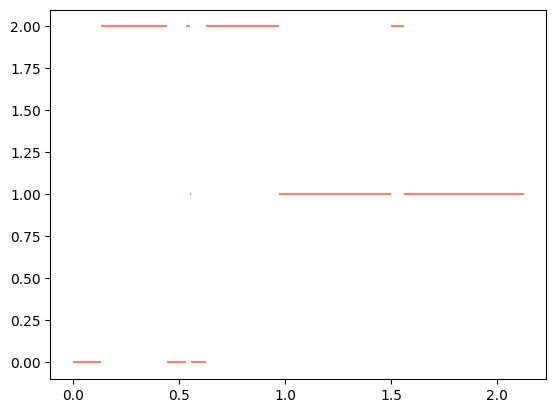

In [12]:
x, t = model_markov_process(Q_matrix, num_steps=10)
draw_markov_process(x, t)

2. Пусть Xt – марковский процесс с интенсивностью перехода i**2 из состояния i в i + 1. Моделировать процесс и построить его траекторию. Что мы наблюдаем в нашем процессе?

In [10]:
def model_boom_chain(num_steps = 20):
    x = np.zeros(num_steps)
    t = np.zeros(num_steps)
    for i in range(num_steps):
        x[i] = i+1
        t[i] = stats.expon.rvs(scale = 1/(i+1)**1)
    return x, t


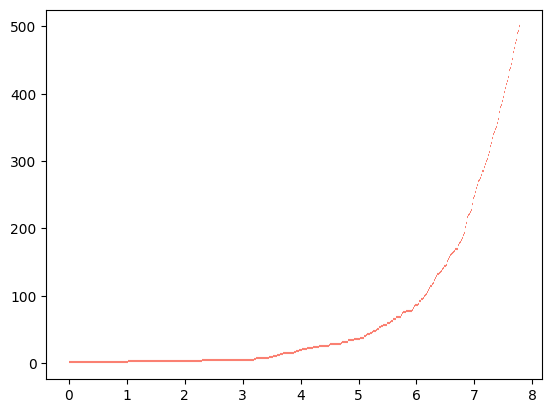

In [13]:
x,t  = model_boom_chain(500)
draw_markov_process(x, t)

3. В парикмахерскую с тремя парикмахерами приходят клиенты с интенсивностью λ, парикмахеры обслуживают клиентов с интенсивностью μ. Если все парикмахеры заняты, то клиент садится в очередь.
Моделировать процесс при а) λ = 1, μ = 1, б) λ = 4, μ = 1.

In [6]:
def model_barber(lamda, mu, num_steps = 10):
    state = 0
    num_barbers = 3
    x = np.zeros(num_steps)
    t = np.zeros(num_steps)
    t[0] = stats.expon.rvs(scale = 1/lamda)
    for i in range(1, num_steps):
        x[i], t[i] = get_state_time(lamda, mu, x[i-1])
    return x, t  

def get_state_time(lamda, mu, state):
    if state == 0:
        new_state = 1
        new_time = stats.expon.rvs(scale = 1/(lamda+mu))
    elif state in [1, 2, 3]:
        new_state = random.choices([state - 1, state + 1], weights = [state*mu/(lamda+state*mu), lamda/(lamda+state*mu)], k=1)[0]
        if new_state == 4:
            new_time = stats.expon.rvs(scale = 1/(lamda+3*mu))
        else:
            new_time = stats.expon.rvs(scale = 1/(lamda+mu*new_state))
    else:
        new_state = random.choices([state - 1, state + 1], weights = [state*mu/(lamda+3*mu), lamda/(lamda+3*mu)], k=1)[0]
        new_time = stats.expon.rvs(scale = 1/(lamda+3*mu))
    return new_state, new_time



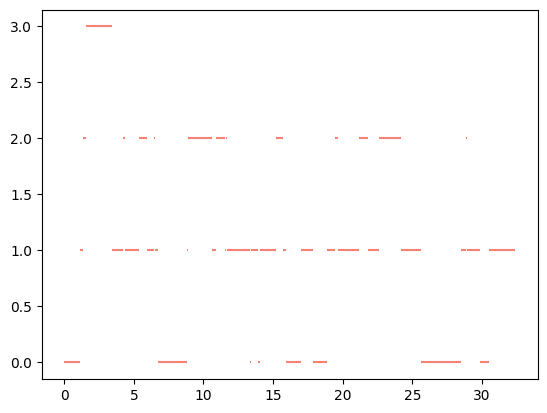

In [19]:
x, t = model_barber(1,1, 50)
draw_markov_process(x, t)

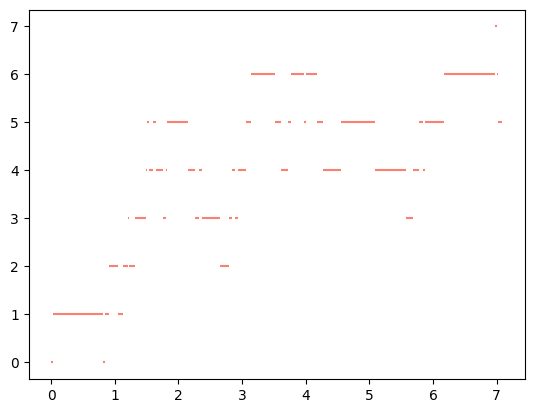

In [20]:
x, t = model_barber(4, 1, 50)
draw_markov_process(x, t)

4. Моделировать марковский процесс Xt


−5 1 3 1

1 −3 1 1

3 1 −5 1

1 1 1 −3


Найдем стационарное распределение Q и сравним его со стационарными распределениями двух марков-
ских цепей а) вложенной цепи б*) цепи, полученной измерением ЦМ через независимые exp(1) времена.

Для оценки стационарного распределения марковских цепей будем считать долю времени, проведенного
цепью в каждом из состояний за длительное время.

In [16]:
def find_erg(matrix):
    # find true stationary distribution of a markov chain
    eigvals, eigvects = np.linalg.eig(np.transpose(matrix))
    index_1 = np.argmin(np.abs(eigvals - 1))
    pi = np.real(eigvects[:,index_1])
    pi = pi/np.sum(pi)
    return pi

def find_erg_continuous(q_matrix, num_steps = 100):
    # get empirical stationary distribution of continuous markov process 
    # via proportions of time spent in a state
    n = q_matrix.shape[0]
    x, t = model_markov_process(q_matrix, num_steps=num_steps)
    time_spent_instate = np.zeros(n)
    time_all = 0
    for i in range(num_steps):
        state = int(x[i])
        time_spent_instate[state] += t[i]
        time_all += t[i]
    time_spent_instate /= time_all
    return time_spent_instate


def find_erg_observed(q_matrix, num_observations = 100):
    n = q_matrix.shape[0]
    num_steps = num_observations*10
    observation_intervals = stats.uniform.rvs( size = num_observations) # time between observations
    observation_times = np.cumsum(observation_intervals)
    observations = np.zeros(num_observations)

    x, t  = model_markov_process(q_matrix, num_steps = num_steps)
    time_prev = 0
    time_cur = t[0]
    cur_obs = 0 # index of the current observation
    j = 0
    time_sum = 0
    for i in range(num_observations):
        while time_sum < observation_times[i]:
            time_sum += t[j]
            j += 1
            if j >= num_steps:
                print("NOT ENOUGH TIME")
                break
        observations[i] = int(x[j-1])
    obs_prob = np.zeros(n)
    for i in range(num_observations):
        state = int(observations[i])
        obs_prob[state] += 1/num_observations
    return obs_prob


In [18]:
Q_matrix = np.array([[-5, 1,3,1],
                     [1, -5, 3, 1],
                     [3, 1, -5, 1],
                     [1,1,3,-5]])

num_steps = 10000

# get inner markov chain and stationary distribution
transition_matrix = find_inner_mc(Q_matrix)
inner_erg = find_erg(transition_matrix)

cont_erg = find_erg_continuous(Q_matrix, num_steps = num_steps) 

obs_erg = find_erg_observed(Q_matrix, num_observations = num_steps)

print(f'Inner MC : {inner_erg}')
print(f'Continuous MC : {cont_erg}')
print(f'Observed MC : {obs_erg}')

Inner MC : [0.29166667 0.16666667 0.375      0.16666667]
Continuous MC : [0.28935513 0.17863056 0.37638398 0.15563032]
Observed MC : [0.2886 0.166  0.377  0.1684]


5.  *В файле nerve.txt содержатся промежутки между нервными импульсами, проходящими по нейронам.
Основная гипотеза заключается в том, что они независимые экспоненциальные. Построим процесс, который подпрыгивает на 1 через наши промежутки. Проверим, что длительность пребывания в состоянии с начала и до конца такая же как ”оставшаяся”. 

Иначе говоря, возьмем исходную последовательность промежутков и построим ее гистограмму, а также выберем случайные точки на прямой (равномерно
на накрытой промежутками части) и для каждой рассмотрим оставшееся время до ближайшего скачка
нашего процесса, у полученного набора оставшихся времен построим гистограмму. Будут ли две наших
гистограммы похожи (то есть выполнено ли свойство ”новое такое же как старое”? Проверить эти две
последовательности на однородность по критерию Манна-Уитни-Уилкоксона.

P-value for Mann-Whitney = 0.6444168392701479


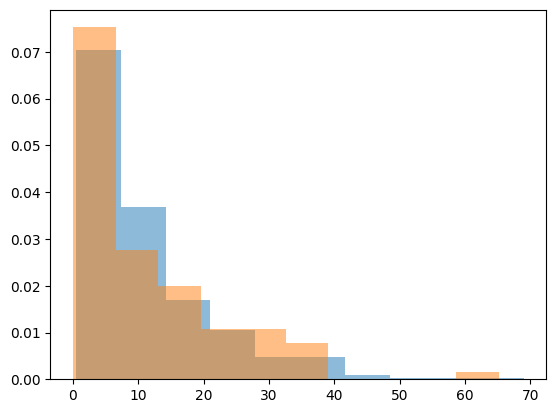

In [37]:
with open('nerve.txt', 'r') as f:
    nerve = [float(line.strip()) for line in f if line.strip()]

num_steps = len(nerve)
num_observations = 100
time_full = np.sum(nerve) #время измерения
observation_times = stats.uniform.rvs(scale = time_full, size = num_observations)
observation_times = np.sort(observation_times)
excess = []

time_sum = 0
j = 0
for i in range(num_observations):
    while time_sum < observation_times[i]:
        time_sum += nerve[j]
        j += 1
    excess.append(time_sum - observation_times[i])

plt.hist(nerve, density = True,  alpha = 0.5);
plt.hist(excess, density = True, alpha = 0.5);
#print(excess)

stat, pval = stats.mannwhitneyu(nerve, excess)
print(f'P-value for Mann-Whitney = {pval}')